案例说明：该项目聚焦于利用深度学习模型，在Fer2013面部表情识别数据集（含35,887张涵盖7种情绪的灰度图像）上开展迁移学习研究，通过重新训练模型最后一层以适配数据集的7分类任务，并采用多轮训练优化准确率，同时针对数据集中可能存在的类别不平衡问题及图像噪声，提出利用数据预处理技术进一步提升性能，最终通过准确率、敏感度、特异度等多元指标评估模型效果。 
### 注意：已有代码请勿修改，在***处编写代码，并将指定区域的代码及结果上传至竞赛平台上。


In [1]:
import cv2
import pandas as pd
import numpy as np
import scikitplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import models,layers,optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

1：使用 pandas 从路径 'datasets/fer2013/fer2013.csv' 读取面部表情数据集文件，输出数据的形状（行数和列数），并展示前5行样本数据。  
注意：本题须同时上传代码和运行结果。   

In [2]:
######上传此部分代码(Upload the Code)######
import pandas as pd
df = pd.read_csv('datasets/fer2013/fer2013.csv')
print(df.shape)
print(df.head())
######上传此部分代码(Upload the Code)######

(35887, 3)
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


2：从 df 数据框的'emotion'列中提取所有唯一的（不重复的）情绪标签值。  

In [3]:
######上传此部分代码(Upload the Code)######
print(df['emotion'].unique())
######上传此部分代码(Upload the Code)######

[0 2 4 6 3 5 1]


3：统计 df 数据框的 emotion 列中每个情绪标签的出现次数，并按降序排列。  
注意：本题须同时上传代码和运行结果。   

In [4]:
######上传此部分代码(Upload the Code)######
print(df['emotion'].value_counts().sort_values(ascending=False))
######上传此部分代码(Upload the Code)######

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


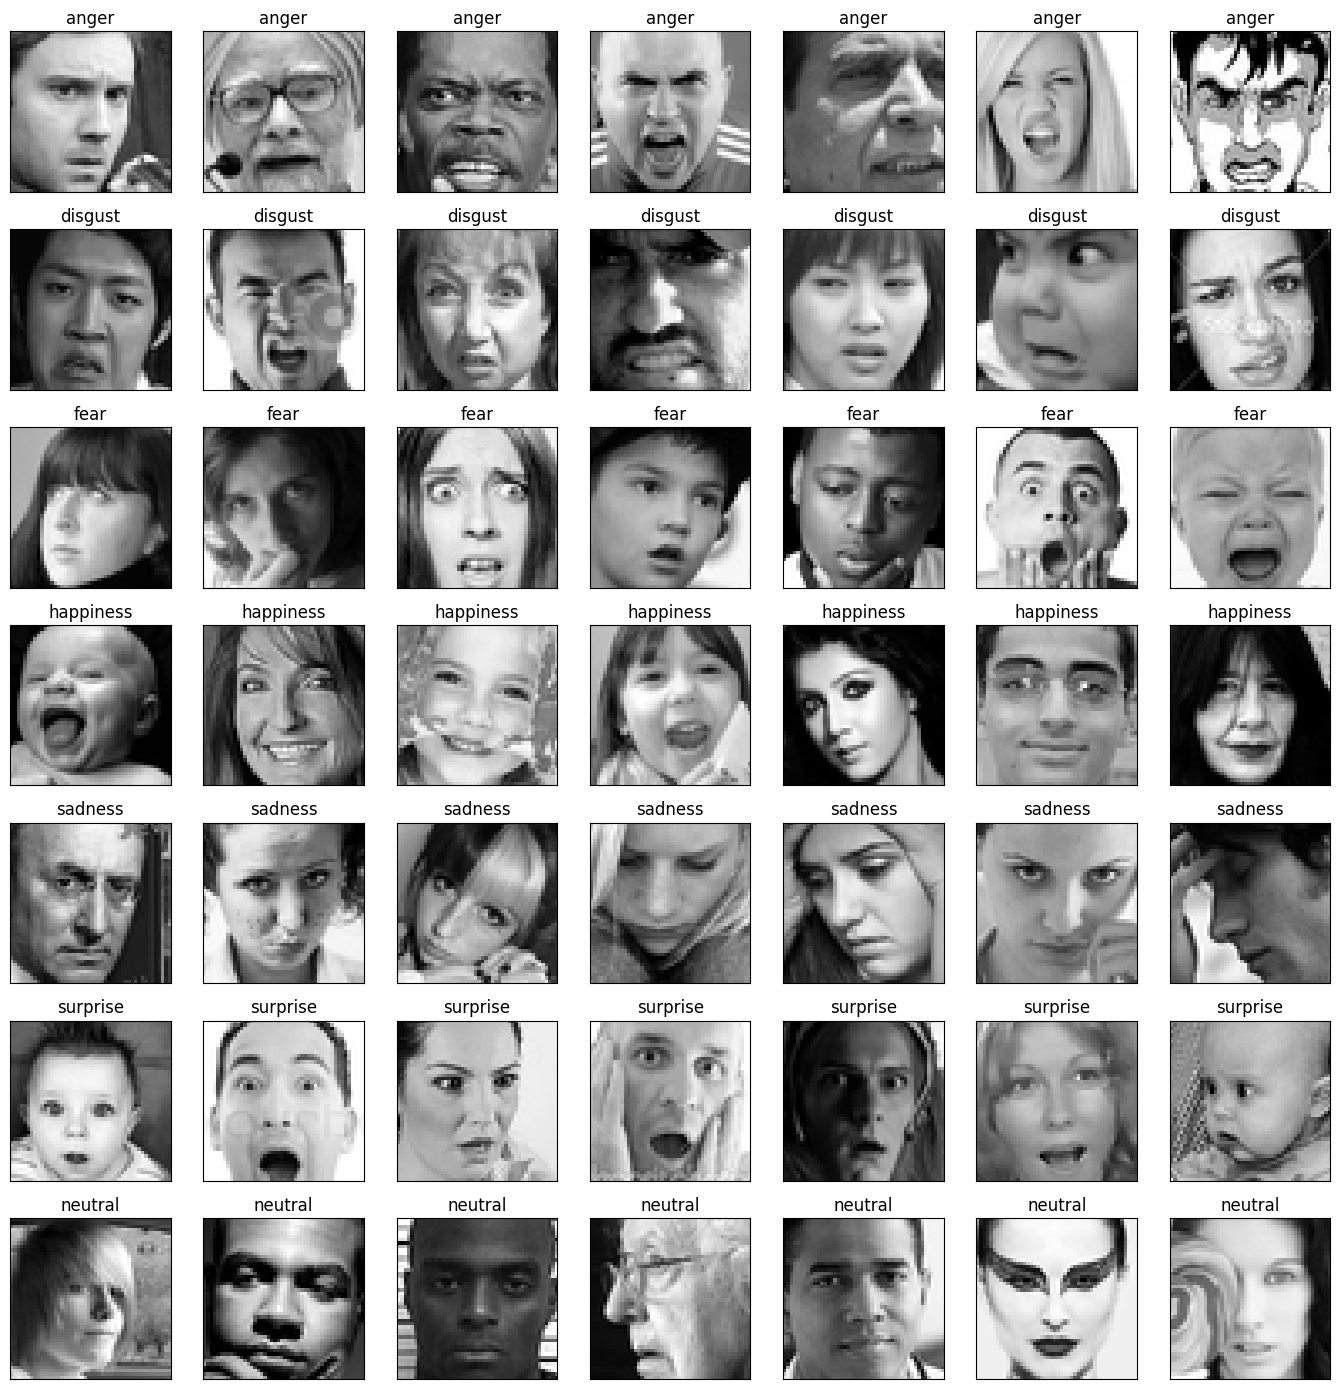

In [5]:
emotion_label_to_text = {0:'anger', 1:'disgust', 2:'fear', 3:'happiness', 
                         4: 'sadness', 5: 'surprise', 6: 'neutral'}
fig = plt.figure(figsize=(14, 14))
k = 0
for label in sorted(df.emotion.unique()):
    for j in range(7):
        px = df[df.emotion==label].pixels.iloc[k]
        px = np.array(px.split(' ')).reshape(48, 48).astype('float32')

        k += 1
        ax = plt.subplot(7, 7, k)
        ax.imshow(px, cmap = 'gray')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(emotion_label_to_text[label])
        plt.tight_layout()

4：将 df.pixels 列中的字符串像素数据转换为 NumPy 数组，重塑为 48×48 的灰度图像，再转换为 RGB 格式，赋值给变量 img_feature.  

(35887, 48, 48, 3)


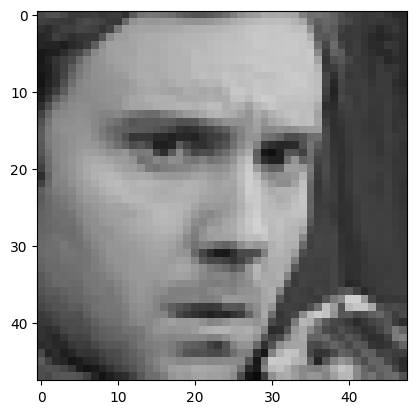

In [6]:
######上传此部分代码(Upload the Code)######
img_features = np.array([cv2.cvtColor(np.array(pixels.split(), dtype=np.float32).reshape(48, 48), cv2.COLOR_GRAY2RGB) for pixels in df['pixels']])
######上传此部分代码(Upload the Code)######
print(img_features.shape)
plt.imshow(img_features[0].astype(np.uint8))

5：使用pandas将 df 数据框中的 'emotion' 列转换为 One-Hot 编码格式的 NumPy 数组，并赋值给变量 img_labels。   
注意：本题须同时上传代码和运行结果。  

In [7]:
######上传此部分代码(Upload the Code)######
img_labels = pd.get_dummies(df['emotion']).values
######上传此部分代码(Upload the Code)######
print(img_labels.shape)

(35887, 7)


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(img_features, 
                                                      img_labels, 
                                                      shuffle = True, 
                                                      stratify = img_labels, 
                                                      test_size = 0.1, 
                                                      random_state = 42)

6：将训练集 (X_train) 和验证集 (X_valid) 的像素值归一化到 [0, 1]，返回变量X_train和X_valid。  

In [9]:
######上传此部分代码(Upload the Code)######
X_train = X_train / 255.0
X_valid = X_valid / 255.0
######上传此部分代码(Upload the Code)######
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((32298, 48, 48, 3), (3589, 48, 48, 3), (32298, 7), (3589, 7))

7：根据模型摘要图，搭建卷积神经网络。  
<img src="./datasets/CNN1.png" width="500">

In [10]:
######上传此部分代码(Upload the Code)######
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])
model.summary()
######上传此部分代码(Upload the Code)######

c:\Users\ybli\Desktop\AI\.conda\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,487 (2.49 MB)

 Trainable params: 652,039 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

8：定义一个 EarlyStopping 回调函数early_stopping，在验证集准确率（val_accuracy）连续 11 个训练周期（epoch）提升幅度小于 0.005 时提前停止训练，并恢复至效果最好的权重，同时输出详细日志信息。  

In [11]:
######上传此部分代码(Upload the Code)######
early_stopping = EarlyStopping(monitor='val_accuracy', 
                               min_delta=0.005, 
                               patience=11, 
                               restore_best_weights=True, 
                               verbose=1)
######上传此部分代码(Upload the Code)######

lr_scheduler = ReduceLROnPlateau(monitor = 'val_accuracy', 
                                 factor = 0.5, 
                                 patience = 7,
                                 min_lr = 1e-7,
                                 verbose = 1)
callbacks = [early_stopping,lr_scheduler]

In [12]:
model.compile(optimizer = "Adam", 
              loss = "categorical_crossentropy", 
              metrics = ["accuracy"])
history = model.fit(X_train, y_train, 
                    batch_size = 256, 
                    epochs = 10,
                    validation_data = (X_valid, y_valid),
                    callbacks=callbacks)

Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 42s 313ms/step - accuracy: 0.2322 - loss: 2.7868 - val_accuracy: 0.1686 - val_loss: 2.9345 - learning_rate: 0.0010
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - accuracy: 0.3540 - loss: 2.1477 - val_accuracy: 0.1814 - val_loss: 2.4296 - learning_rate: 0.0010
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 39s 306ms/step - accuracy: 0.4050 - loss: 1.9019 - val_accuracy: 0.3653 - val_loss: 1.9081 - learning_rate: 0.0010
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 39s 306ms/step - accuracy: 0.4507 - loss: 1.7126 - val_accuracy: 0.4255 - val_loss: 1.7437 - learning_rate: 0.0010
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 40s 311ms/step - accuracy: 0.4780 - loss: 1.5766 - val_accuracy: 0.4698 - val_loss: 1.5831 - learning_rate: 0.0010
Epoch 6/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 322ms/step - accuracy: 0.5074 - loss: 1.4598 - val_accuracy: 0.4227 - val_loss: 1.6041 - learning_rate: 0.0010
Epoch 7/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 322ms/step - accuracy: 0.5

9：在第2个子图中，绘制训练和验证的损失（loss）随训练轮次（epoch）变化的曲线，并添加标题“Loss”和图例。  

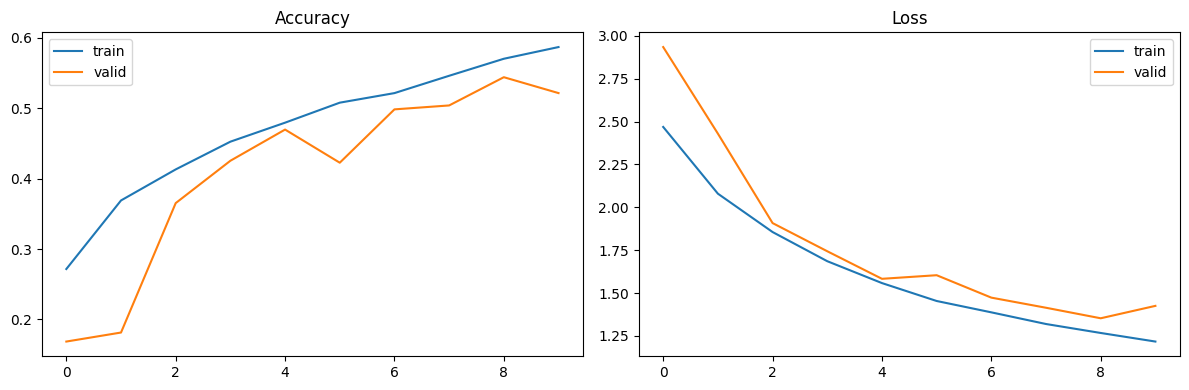

In [13]:
fig = plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(history.epoch, history.history['accuracy'], label='train')
ax1.plot(history.epoch, history.history['val_accuracy'], label='valid')
ax1.set_title('Accuracy')
ax1.legend()

######上传此部分代码(Upload the Code)######
ax2 = plt.subplot(1, 2, 2)
ax2.plot(history.epoch, history.history['loss'], label='train')
ax2.plot(history.epoch, history.history['val_loss'], label='valid')
ax2.set_title('Loss')
ax2.legend()
######上传此部分代码(Upload the Code)######

plt.tight_layout()
plt.show()

10：使用验证集数据 X_valid 生成预测标签 yhat_valid，并与真实标签 y_valid（转换为类别索引后）绘制混淆矩阵，图像尺寸设为 7×7 英寸。  

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


<Figure size 700x700 with 0 Axes>

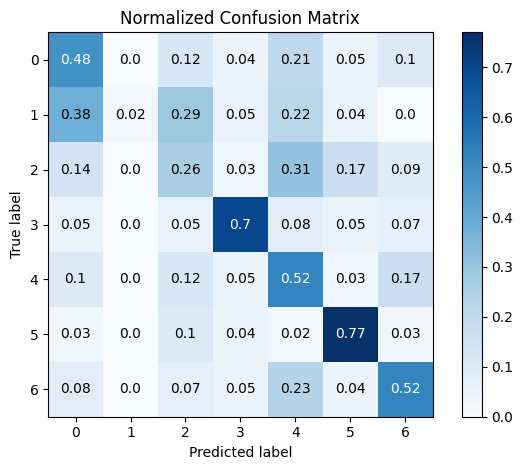

total wrong validation predictions: 1636


              precision    recall  f1-score   support

           0       0.47      0.48      0.48       495
           1       1.00      0.02      0.04        55
           2       0.33      0.26      0.29       512
           3       0.84      0.70      0.77       899
           4       0.39      0.52      0.44       608
           5       0.60      0.77      0.68       400
           6       0.54      0.52      0.53       620

    accuracy                           0.54      3589
   macro avg       0.60      0.47      0.46      3589
weighted avg       0.56      0.54      0.54      3589



<Figure size 640x480 with 0 Axes>

In [14]:
######上传此部分代码(Upload the Code)######
yhat_valid = np.argmax(model.predict(X_valid), axis=1)
plt.figure(figsize=(7, 7))
scikitplot.metrics.plot_confusion_matrix(np.argmax(y_valid, axis=1), yhat_valid, normalize=True)
plt.tight_layout()
######上传此部分代码(Upload the Code)######

print(f'total wrong validation predictions: {np.sum(np.argmax(y_valid, axis=1) != yhat_valid)}\n\n')
print(classification_report(np.argmax(y_valid, axis=1), yhat_valid))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


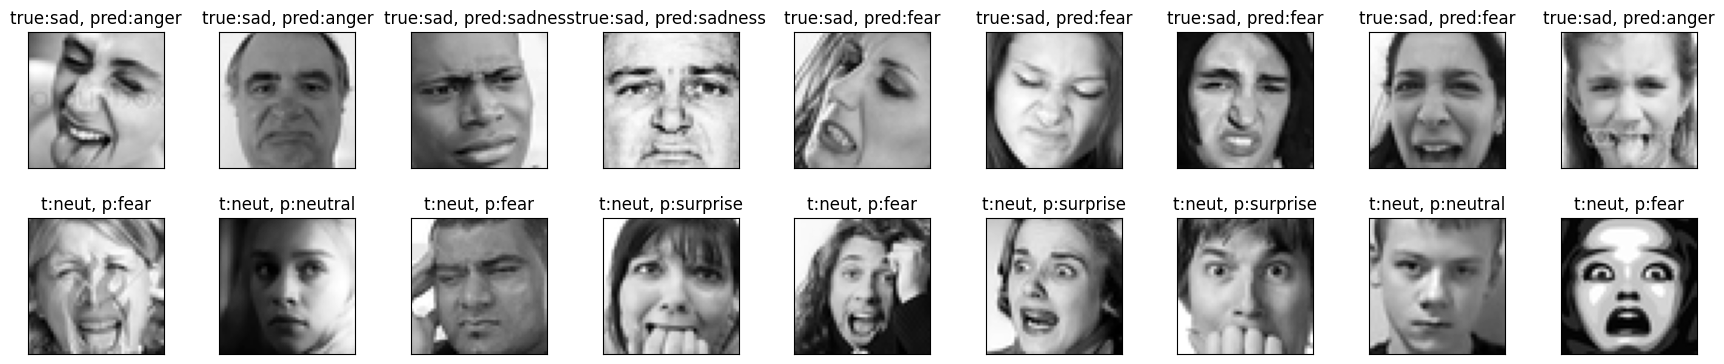

In [15]:
mapper = {
    0: 'anger',
    1: 'disgust',
    2: 'fear',
    3: 'happiness',
    4: 'sadness',
    5: 'surprise',
    6: 'neutral'
}
np.random.seed(5)
random_sad_imgs = np.random.choice(np.where(y_valid[:, 1]==1)[0], size=9)
random_neutral_imgs = np.random.choice(np.where(y_valid[:, 2]==1)[0], size=9)

fig =plt.figure(figsize=(18, 4))
for i, (sadidx, neuidx) in enumerate(zip(random_sad_imgs, random_neutral_imgs)):
        ax = plt.subplot(2, 9, i+1)
        sample_img = X_valid[sadidx,:,:,0]
        ax.imshow(sample_img, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        sample_img = cv2.cvtColor(sample_img, cv2.COLOR_GRAY2RGB)

        ax.set_title(f"true:sad, pred:{mapper[np.argmax(model.predict(sample_img.reshape(1,48,48,3))[0])]}")

        ax = plt.subplot(2, 9, i+10)
        sample_img = X_valid[neuidx,:,:,0]
        ax.imshow(sample_img, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        sample_img = cv2.cvtColor(sample_img, cv2.COLOR_GRAY2RGB)
        
        ax.set_title(f"t:neut, p:{mapper[np.argmax(model.predict(sample_img.reshape(1,48,48,3))[0])]}")

        plt.tight_layout(pad=2.0)